In [ ]:
!pip install --q ipython-autotime
%load_ext autotime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.7 MB/s eta 0:00:00
time: 352 µs (started: 2024-07-01 03:20:36 +00:00)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras

time: 7.53 s (started: 2024-07-01 03:20:36 +00:00)


## 1.데이터 준비

In [ ]:
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

4422102/4422102 [==============================] - 1s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
time: 3.88 s (started: 2024-07-01 03:20:43 +00:00)


In [ ]:
columns = ['T-shirt/top', 'Trouser',  'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

time: 565 µs (started: 2024-07-01 03:20:47 +00:00)


## 2.데이터 확인

In [ ]:
# np.random.seed(42)
sample = np.random.randint(60000, size=25)
sample

array([ 7368, 52496, 56719,  8265, 30803, 21013, 14063, 55513,  4244,
        9066,  1686, 45935, 16771, 13153,  9151, 52646, 45522, 23349,
       23145, 40151,  2516, 19350, 52745,  2355, 10412])

time: 10.8 ms (started: 2024-07-01 03:20:47 +00:00)


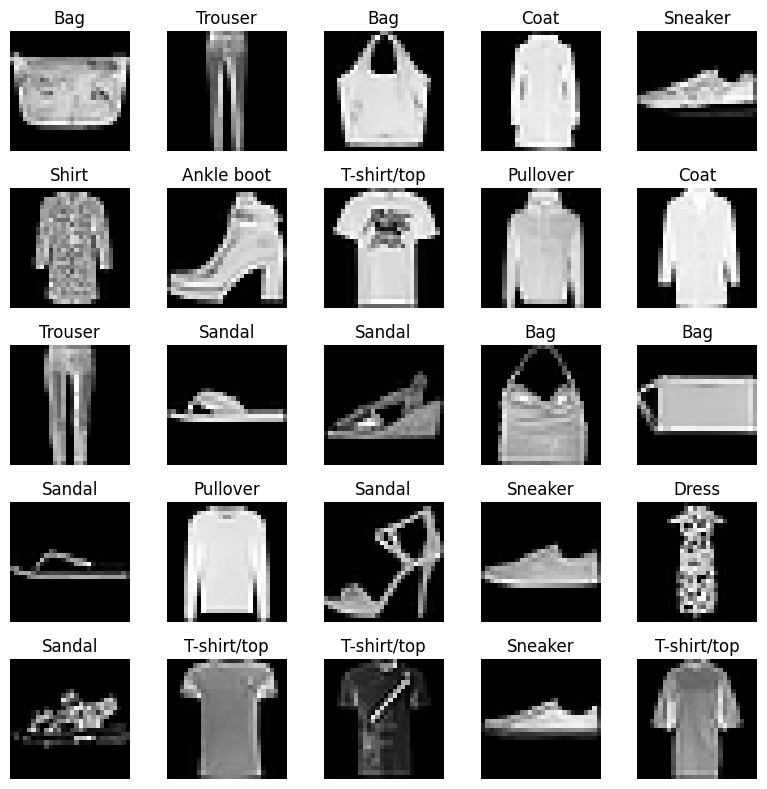

time: 3.03 s (started: 2024-07-01 03:20:47 +00:00)


In [ ]:
fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(columns[y_train[idx]])
fig.tight_layout()
plt.show()

In [ ]:
pd.Series(y_train).value_counts().sort_index()

0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

time: 20.2 ms (started: 2024-07-01 03:20:50 +00:00)


## 3.학습용, 검증용 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(48000, 28, 28) (12000, 28, 28)
(48000,) (12000,)
time: 389 ms (started: 2024-07-01 03:20:50 +00:00)


## 4.전처리
- X_train, X_val : Min-Max 스케일링
- y_train, y_val : 원핫인코딩

In [ ]:
# Min-Max Scaling

X_train_s = X_train / 255.
X_val_s = X_val / 255.

time: 230 ms (started: 2024-07-01 03:20:51 +00:00)


In [ ]:
# y의 원핫인코딩
from keras.utils import to_categorical

y_train_o = to_categorical(y_train)
y_val_o = to_categorical(y_val)

time: 4.28 ms (started: 2024-07-01 03:20:51 +00:00)


In [ ]:
print(X_train_s.shape, X_val_s.shape)
print(y_train_o.shape, y_val_o.shape)

(48000, 28, 28) (12000, 28, 28)
(48000, 10) (12000, 10)
time: 791 µs (started: 2024-07-01 03:20:51 +00:00)


## 5.모델
- CNN 모델

In [ ]:
X_train_s = X_train_s.reshape(-1, 28, 28, 1)
X_val_s = X_val_s.reshape(-1, 28, 28, 1)

X_train_s.shape, X_val_s.shape

((48000, 28, 28, 1), (12000, 28, 28, 1))

time: 7.51 ms (started: 2024-07-01 03:20:51 +00:00)


In [ ]:
from keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(28, 28, 1)),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

time: 1.68 s (started: 2024-07-01 03:20:51 +00:00)


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 16)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 13, 13, 16)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 800)               0

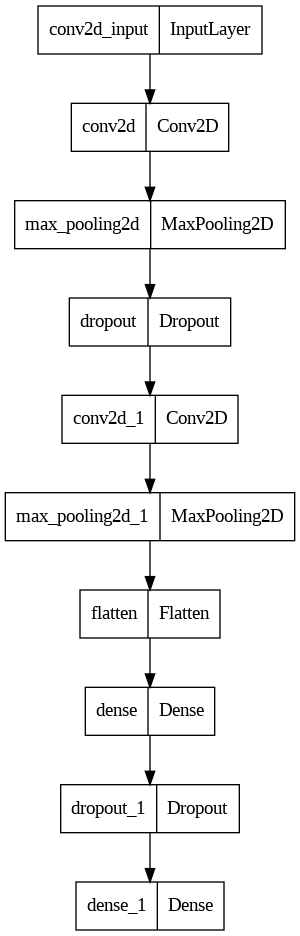

time: 366 ms (started: 2024-07-01 03:20:53 +00:00)


In [ ]:
keras.utils.plot_model(model)

In [ ]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=['accuracy'])

time: 65.3 ms (started: 2024-07-01 03:20:53 +00:00)


In [ ]:
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train_o,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_s, y_val_o))


Epoch 1/30
1500/1500 [==============================] - 16s 5ms/step - loss: 0.5910 - accuracy: 0.7811 - val_loss: 0.4162 - val_accuracy: 0.8441
Epoch 2/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4045 - accuracy: 0.8510 - val_loss: 0.3570 - val_accuracy: 0.8673
Epoch 3/30
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3509 - accuracy: 0.8708 - val_loss: 0.3241 - val_accuracy: 0.8802
Epoch 4/30
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3168 - accuracy: 0.8816 - val_loss: 0.3060 - val_accuracy: 0.8868
Epoch 5/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2986 - accuracy: 0.8892 - val_loss: 0.2757 - val_accuracy: 0.8980
Epoch 6/30
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2800 - accuracy: 0.8952 - val_loss: 0.2736 - val_accuracy: 0.8981
Epoch 7/30
1500/1500 [==============================] - 7s 5ms/step - loss: 0.2626 - accuracy: 0.9011 - val_loss: 0.2670 - val_accuracy

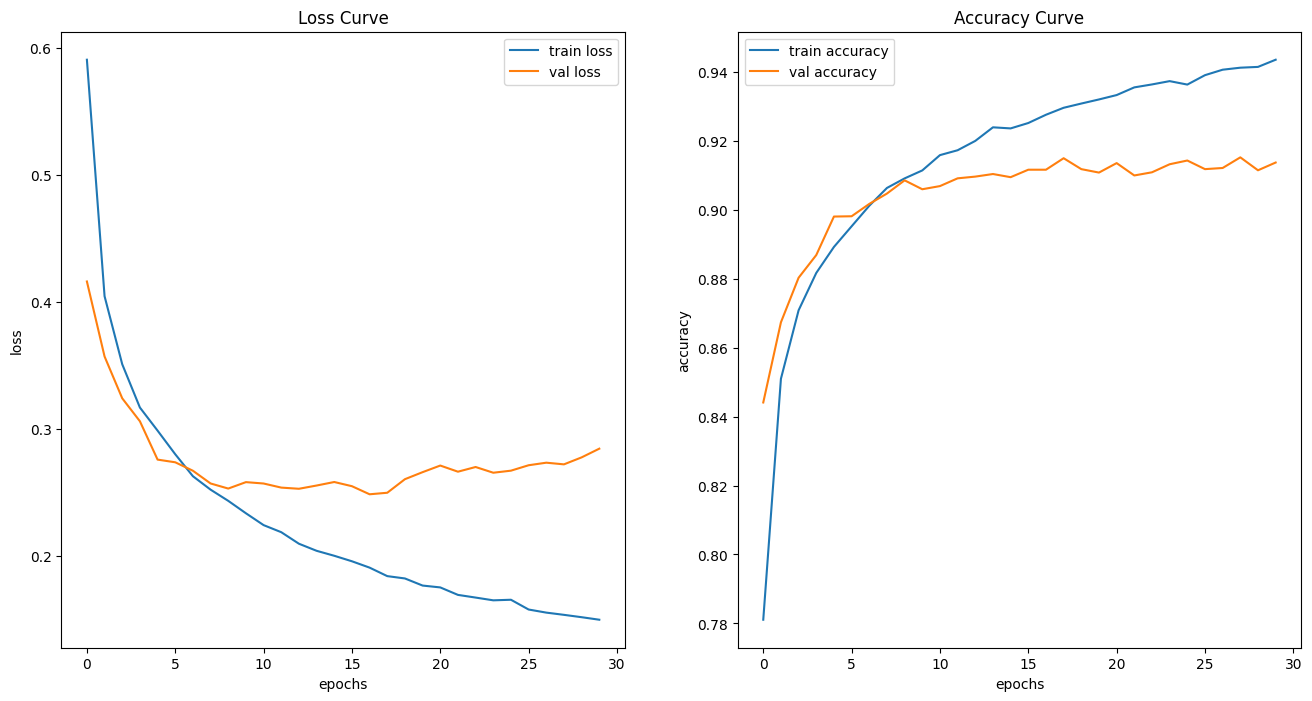

time: 530 ms (started: 2024-07-01 03:25:25 +00:00)


In [ ]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

## 6.평가

In [ ]:
X_test_s = X_test / 255.
X_test_s = X_test_s.reshape(-1, 28, 28, 1)
y_test_o = to_categorical(y_test)

time: 22.7 ms (started: 2024-07-01 03:26:06 +00:00)


In [ ]:
y_pred = model.predict(X_test_s)

y_pred[:10]

313/313 [==============================] - 1s 2ms/step


array([[2.31661614e-13, 1.08452142e-14, 1.63852300e-11, 1.03894405e-13,
        1.60895806e-20, 1.51844859e-09, 1.16029487e-14, 3.26664491e-07,
        2.29809834e-12, 9.99999642e-01],
       [1.52772017e-10, 2.89572128e-25, 9.99999285e-01, 1.59312432e-16,
        3.63339808e-07, 1.12886859e-21, 3.20828860e-07, 1.17478792e-20,
        2.53779753e-15, 1.59250665e-21],
       [9.05503372e-20, 1.00000000e+00, 1.99454397e-28, 1.24972188e-27,
        2.27115003e-29, 0.00000000e+00, 6.59204072e-25, 0.00000000e+00,
        1.08582709e-34, 0.00000000e+00],
       [1.76435772e-16, 1.00000000e+00, 2.05256508e-21, 1.19132321e-14,
        6.17583038e-17, 3.66800458e-31, 3.37998783e-16, 0.00000000e+00,
        2.83692947e-27, 0.00000000e+00],
       [1.40666112e-01, 4.32101195e-11, 9.06239450e-03, 9.59514182e-06,
        9.52729839e-04, 2.09206719e-09, 8.49309146e-01, 3.19488949e-11,
        5.49878987e-09, 3.41920483e-08],
       [6.41612527e-11, 1.00000000e+00, 1.55234672e-19, 3.14692592e-17,
   

time: 1.05 s (started: 2024-07-01 03:26:08 +00:00)


In [ ]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([9, 2, 1, ..., 8, 1, 5])

time: 3.61 ms (started: 2024-07-01 03:26:13 +00:00)


accuracy: 0.9077
recall: 0.9077
precision: 0.9073522949060067
f1 : 0.9071528999084725


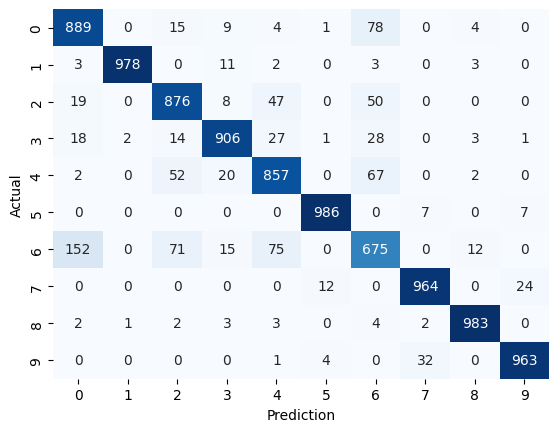

time: 828 ms (started: 2024-07-01 03:27:02 +00:00)


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred ,average=aver))
    print('precision:', precision_score(y_true, y_pred,average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

print_metrics(y_test, y_pred, aver='macro')

## 7.모델저장

In [ ]:
model.save('cnn_muti_fashion.h5')

time: 39.7 ms (started: 2024-07-01 03:30:28 +00:00)


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
model.save('cnn_muti_fashion.keras')

time: 146 ms (started: 2024-07-01 03:31:30 +00:00)


In [ ]:
model.save('cnn_muti_fashion')

time: 1.49 s (started: 2024-07-01 03:32:06 +00:00)


In [ ]:
loaded_model = keras.saving.load_model('/content/cnn_muti_fashion.h5')

time: 355 ms (started: 2024-07-01 03:34:40 +00:00)


In [ ]:
loaded_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 16)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 13, 13, 16)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 800)               0